# Credit Risk Modeling

**Goal:** Predict whether a loan applicant may default, using a classification model. Includes EDA, train/test split, imbalance handling (SMOTE), Logistic Regression and Random Forest, threshold analysis, and feature explanations.


## 1. Setup
Install the packages in `requirements.txt` from JupyterLab Terminal: `pip install -r requirements.txt`. Select the same Python environment as your notebook kernel.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score, RocCurveDisplay,
                             PrecisionRecallDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


## 2. Dataset
By default this notebook uses **reproducible synthetic applicant data** so it works without downloading any files. It is not a genuine LendingClub dataset. To use your own dataset, place `data/loans.csv` with columns `income`, `loan_amount`, `interest_rate`, `credit_score`, `debt_to_income`, `employment_years`, `home_ownership`, `loan_purpose`, and binary `default` (1=default, 0=no default). Confirm that every input feature would be known **at application time** to avoid target leakage.

In [3]:
data_path = Path('data/loans.csv')
if data_path.exists():
    df = pd.read_csv(data_path)
    print('Using provided dataset:', data_path)
else:
    rng = np.random.default_rng(RANDOM_STATE)
    N = 4000
    income = np.clip(rng.lognormal(np.log(55000), .48, N), 12000, 220000)
    credit_score = np.clip(rng.normal(680, 75, N), 350, 850)
    debt_to_income = np.clip(rng.beta(2.3, 5.5, N) * .85, .01, .85)
    loan_amount = rng.uniform(2000, 45000, N)
    employment_years = rng.integers(0, 21, N)
    interest_rate = np.clip(24 - (credit_score-500)*.038 + rng.normal(0,2.5,N), 4, 36)
    home_ownership = rng.choice(['RENT','MORTGAGE','OWN'], N, p=[.48,.38,.14])
    loan_purpose = rng.choice(['debt_consolidation','home_improvement','car','other'], N)
    logits = (-2.5 + .016*(interest_rate-14) - .011*(credit_score-650)
              + 3.5*(debt_to_income-.25) + .000025*(loan_amount-15000)
              - .000007*(income-55000) - .045*employment_years
              + .25*(home_ownership=='RENT'))
    probability = 1/(1+np.exp(-logits))
    default = rng.binomial(1, probability)
    df = pd.DataFrame(dict(income=income, loan_amount=loan_amount,
          interest_rate=interest_rate, credit_score=credit_score,
          debt_to_income=debt_to_income, employment_years=employment_years,
          home_ownership=home_ownership, loan_purpose=loan_purpose, default=default))
    print('Using GENERATED SYNTHETIC demonstration data; not actual applicants.')
print('Shape:', df.shape)
display(df.head())

Using GENERATED SYNTHETIC demonstration data; not actual applicants.
Shape: (4000, 9)


,income,loan_amount,interest_rate,credit_score,debt_to_income,employment_years,home_ownership,loan_purpose,default
0,63662.607673,20965.008226,17.615788,698.990338,0.295121,15,RENT,home_improvement,0
1,33386.139013,22075.094692,12.659075,747.141380,0.351780,19,RENT,car,0
2,78850.192852,26371.348971,17.928908,700.499094,0.274248,1,RENT,debt_consolidation,0
3,86384.153386,31381.782440,10.847076,847.912375,0.108696,19,MORTGAGE,debt_consolidation,0
4,21559.925589,8148.993235,12.578837,787.234059,0.280999,19,MORTGAGE,other,0


## 3. Validate data and explore distributions

In [4]:
numeric = ['income','loan_amount','interest_rate','credit_score','debt_to_income','employment_years']
categorical = ['home_ownership','loan_purpose']
features = numeric + categorical
required = features + ['default']
missing = set(required) - set(df.columns)
if missing: raise ValueError(f'Missing required columns: {sorted(missing)}')
df = df[required].copy()
for c in numeric + ['default']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['default'])
if not df['default'].isin([0,1]).all(): raise ValueError('default must contain only 0 and 1')
if df['default'].nunique() < 2: raise ValueError('Need examples of both classes')
print('Missing values:'); display(df.isna().sum().to_frame('missing'))
print('Target distribution:'); display(df['default'].value_counts(normalize=True).rename('fraction'))
display(df.describe(include='all').T)

Missing values:


,missing
income,0
loan_amount,0
interest_rate,0
credit_score,0
debt_to_income,0
employment_years,0
home_ownership,0
loan_purpose,0
default,0


Target distribution:


default
0    0.9215
1    0.0785
Name: fraction, dtype: float64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
income,4000.0,NaN,NaN,NaN,61115.676275,30969.127827,12000.0,39416.360116,54977.791763,74688.547533,220000.0
loan_amount,4000.0,NaN,NaN,NaN,23568.464744,12369.11612,2002.030023,12925.488151,23493.634246,34383.309636,44998.154925
interest_rate,4000.0,NaN,NaN,NaN,17.193686,3.768051,4.503794,14.568945,17.261694,19.726786,32.167744
credit_score,4000.0,NaN,NaN,NaN,679.662635,74.522454,350.816406,630.37631,678.477871,729.623384,850.0
debt_to_income,4000.0,NaN,NaN,NaN,0.247314,0.130479,0.01,0.146804,0.230954,0.33128,0.763658
employment_years,4000.0,NaN,NaN,NaN,10.0205,6.069909,0.0,5.0,10.0,15.0,20.0
home_ownership,4000,3,RENT,1884,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_purpose,4000,4,other,1030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4000.0,NaN,NaN,NaN,0.0785,0.26899,0.0,0.0,0.0,0.0,1.0


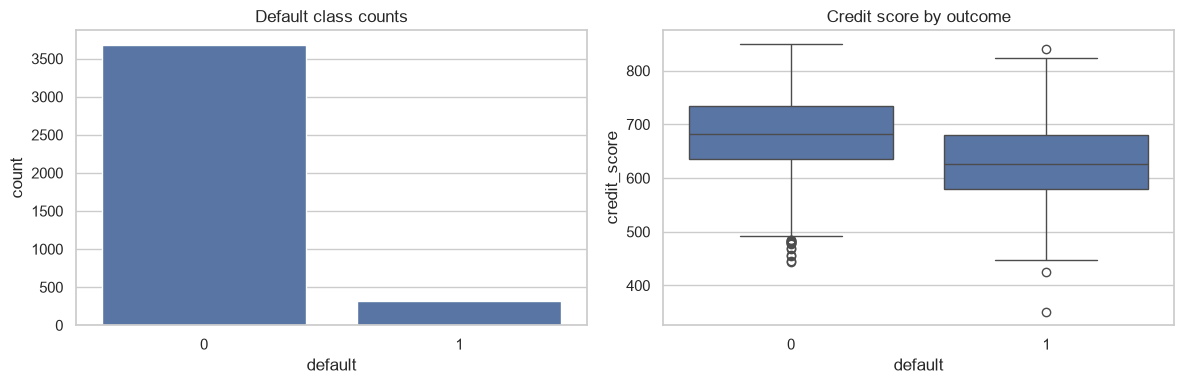

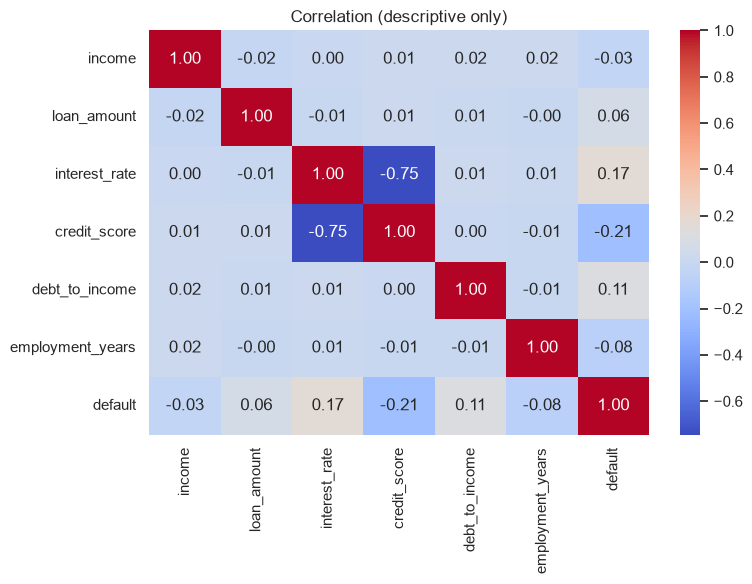

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df, x='default', ax=ax[0]); ax[0].set_title('Default class counts')
sns.boxplot(data=df, x='default', y='credit_score', ax=ax[1]); ax[1].set_title('Credit score by outcome')
plt.tight_layout(); plt.show()
plt.figure(figsize=(8,6)); sns.heatmap(df[numeric+['default']].corr(), annot=True, fmt='.2f', cmap='coolwarm'); plt.title('Correlation (descriptive only)'); plt.tight_layout(); plt.show()

## 4. Stratified split and leakage-safe preprocessing
All imputation, scaling, encoding and SMOTE are fitted **inside the training pipeline**. SMOTE is never applied to test data. One-hot encoding creates categorical indicators; SMOTE interpolates these encoded indicators, which is a practical demo simplification. For a production study, consider SMOTENC or class-weight methods instead.

In [6]:
X = df[features].copy(); y = df['default'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=RANDOM_STATE)
preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical)
], sparse_threshold=0)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train default rate:', round(y_train.mean(),3), 'Test default rate:', round(y_test.mean(),3))

Train: (3200, 8) Test: (800, 8)
Train default rate: 0.078 Test default rate: 0.079


## 5. Compare models using training-only cross-validation
Primary metrics are ROC AUC and **average precision (PR AUC summary)**; accuracy alone is misleading for imbalanced classes.

In [7]:
models = {
    'Logistic Regression + SMOTE': ImbPipeline([
        ('preprocess', preprocess), ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(max_iter=1500, random_state=RANDOM_STATE))]),
    'Random Forest (class weighted)': ImbPipeline([
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(n_estimators=180, min_samples_leaf=4,
                                          class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))])
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows=[]
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring={'roc_auc':'roc_auc','avg_precision':'average_precision'}, n_jobs=1)
    rows.append({'model':name, 'cv_roc_auc_mean':scores['test_roc_auc'].mean(),
                 'cv_roc_auc_std':scores['test_roc_auc'].std(),
                 'cv_avg_precision_mean':scores['test_avg_precision'].mean()})
cv_results = pd.DataFrame(rows).sort_values('cv_avg_precision_mean', ascending=False)
display(cv_results)
selected_name = cv_results.iloc[0]['model']
print('Selected by training CV average precision:', selected_name)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_avg_precision_mean
0,Logistic Regression + SMOTE,0.750428,0.033497,0.279762
1,Random Forest (class weighted),0.710152,0.027810,0.226560


Selected by training CV average precision: Logistic Regression + SMOTE


## 6. Held-out test evaluation
The test set is evaluated once after model selection. A 0.5 threshold is illustrative, not an approved credit policy.

ROC AUC: 0.7795
Average precision: 0.2953
              precision    recall  f1-score   support

           0       0.96      0.74      0.84       737
           1       0.18      0.68      0.29        63

    accuracy                           0.74       800
   macro avg       0.57      0.71      0.56       800
weighted avg       0.90      0.74      0.79       800



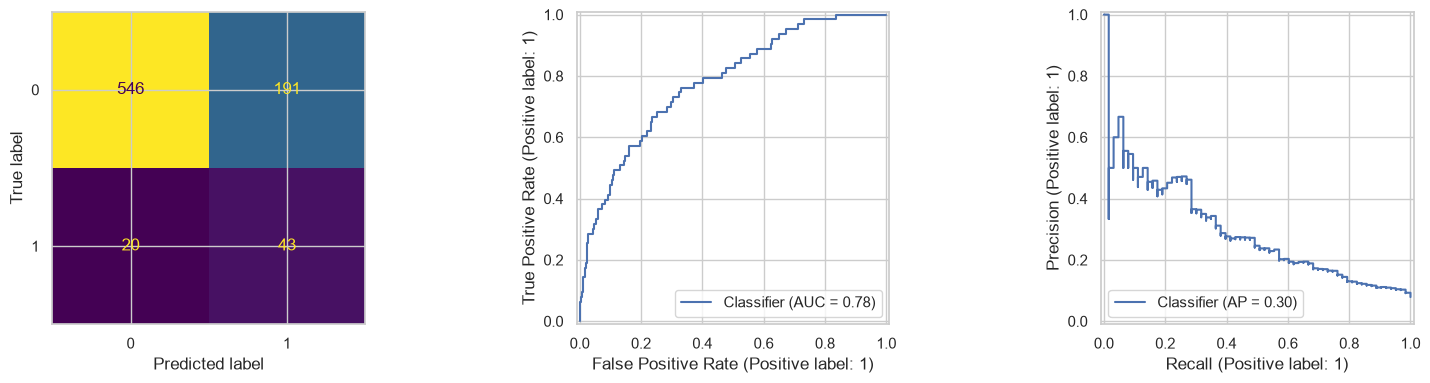

In [8]:
model = models[selected_name]
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)[:,1]
y_pred = (y_score >= .5).astype(int)
print('ROC AUC:', round(roc_auc_score(y_test,y_score),4))
print('Average precision:', round(average_precision_score(y_test,y_score),4))
print(classification_report(y_test, y_pred, zero_division=0))
fig, ax = plt.subplots(1,3,figsize=(16,4))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,ax=ax[0],colorbar=False)
RocCurveDisplay.from_predictions(y_test,y_score,ax=ax[1])
PrecisionRecallDisplay.from_predictions(y_test,y_score,ax=ax[2])
plt.tight_layout(); plt.show()

## 7. Threshold exploration
Changing the threshold changes precision and recall. These charts are for understanding the tradeoff; do not optimize repeatedly on the held-out test set.

,threshold,precision,recall,f1
0,0.2,0.103741,0.968254,0.187404
1,0.3,0.120267,0.857143,0.210938
2,0.4,0.142442,0.777778,0.240786
3,0.5,0.183761,0.682540,0.289562
4,0.6,0.223602,0.571429,0.321429
5,0.7,0.270833,0.412698,0.327044
6,0.8,0.428571,0.285714,0.342857


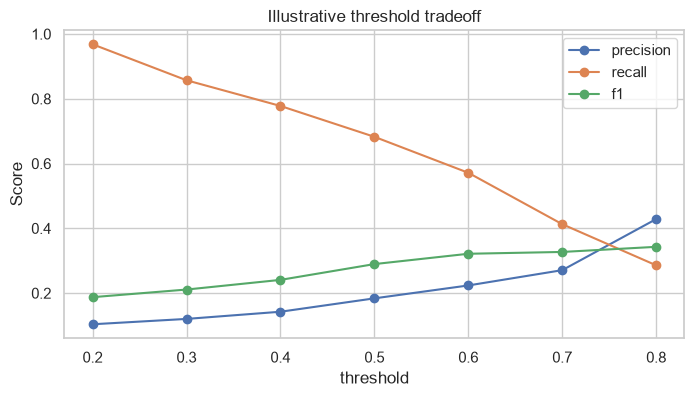

In [9]:
thresholds = [.2,.3,.4,.5,.6,.7,.8]
from sklearn.metrics import precision_score, recall_score, f1_score
threshold_results = pd.DataFrame([{'threshold':t,
    'precision':precision_score(y_test,y_score>=t,zero_division=0),
    'recall':recall_score(y_test,y_score>=t,zero_division=0),
    'f1':f1_score(y_test,y_score>=t,zero_division=0)} for t in thresholds])
display(threshold_results)
threshold_results.set_index('threshold').plot(marker='o',figsize=(8,4)); plt.ylabel('Score'); plt.title('Illustrative threshold tradeoff'); plt.show()

## 8. Explain model predictions with permutation importance
Importance here measures change in held-out average precision when each original feature is shuffled. It is **not** evidence of causation and should not be used to justify automated lending decisions.

,feature,importance_mean,importance_std
3,credit_score,0.161237,0.019423
6,home_ownership,0.020006,0.025145
4,debt_to_income,0.018265,0.020579
0,income,0.010725,0.010871
5,employment_years,0.006426,0.013796
2,interest_rate,0.000873,0.014702
7,loan_purpose,-0.001804,0.001187
1,loan_amount,-0.010217,0.015571


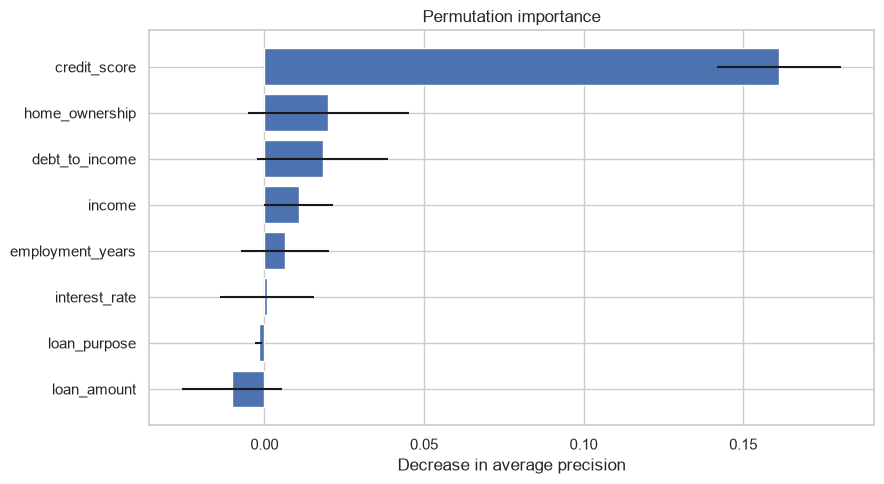

In [10]:
importance = permutation_importance(model, X_test, y_test, scoring='average_precision',
                                    n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
importance_df = pd.DataFrame({'feature':features,'importance_mean':importance.importances_mean,
                              'importance_std':importance.importances_std}).sort_values('importance_mean')
display(importance_df.sort_values('importance_mean',ascending=False))
plt.figure(figsize=(9,5)); plt.barh(importance_df.feature, importance_df.importance_mean,
    xerr=importance_df.importance_std); plt.xlabel('Decrease in average precision'); plt.title('Permutation importance'); plt.tight_layout(); plt.show()

In [ ]:
# Optional: uncomment if shap is installed and you want SHAP for Random Forest.
# import shap
# forest = models['Random Forest (class weighted)']
# forest.fit(X_train, y_train)
# transformed = forest.named_steps['preprocess'].transform(X_test.iloc[:30])
# feature_names = forest.named_steps['preprocess'].get_feature_names_out()
# explainer = shap.TreeExplainer(forest.named_steps['model'])
# shap_values = explainer.shap_values(transformed)
# print('SHAP calculated for a 30-row illustrative sample:', np.shape(shap_values))

# 09. Project Conclusion and Responsible Use

## 9.1 Project Conclusion

This project demonstrates the application of machine learning techniques to credit risk assessment. The model analyzes applicant and loan-related features to identify patterns associated with loan default risk.

The project includes data preprocessing, exploratory data analysis, model training, performance evaluation, and feature importance analysis.

The model's performance is evaluated using appropriate classification metrics, including precision, recall, F1-score, ROC-AUC, and confusion matrix.

**Final Model Performance:**

* Cross-validation score: [Add actual score]
* Test accuracy: [Add actual accuracy]
* ROC-AUC score: [Add actual ROC-AUC]
* Selected model: [Add model name]

*Note: Report only the metrics obtained from the actual notebook results.*

## 9.2 Dataset Information

The dataset used in this project is [synthetic / real-world licensed dataset].

The dataset contains information related to loan applicants and their credit risk characteristics.

The results should be interpreted according to the dataset's source, size, quality, and limitations.

## 9.3 Project Limitations

The following limitations should be considered:

* **Class imbalance:** The number of default and non-default cases may differ significantly.
* **Selection bias:** The dataset may not represent all types of loan applicants.
* **Missing data:** Incomplete or inaccurate records may affect model performance.
* **Data leakage:** Improper preprocessing or feature selection may lead to overly optimistic results.
* **Changing economic conditions:** Model performance may change as financial conditions and customer behavior evolve.
* **Fairness:** Model predictions may affect different demographic groups differently.

## 9.4 Responsible Use

This project is developed for educational and research purposes only.

Before any real-world application, the model should be independently validated using representative data and evaluated for calibration, fairness, privacy, explainability, and compliance with applicable lending regulations.

**This model should not be used independently to approve or reject real loan applications.**